In [1]:
# churn_analysis_complete.ipynb

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Deep Learning (optional)
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load your datasets (FIXED PATHS)
df_uber = pd.read_csv(r"D:\Ride Hailing Churn Analysis\uber_reviews_without_reviewid.csv")
df_ola = pd.read_csv(r"D:\Ride Hailing Churn Analysis\Bengaluru_Ola_Booking_Data.csv")
df_rapido = pd.read_csv(r"D:\Ride Hailing Churn Analysis\Subride - Subjectivity Detection in Ride-Hailing App Reviews.csv")
df_subride_annotator = pd.read_csv(r"D:\Ride Hailing Churn Analysis\Subride - Subjectivity Detection in Ride-Hailing App Reviews Per Annotator.csv")

# Quick view
print(f"Uber: {df_uber.shape}")
print(f"Ola: {df_ola.shape}")
print(f"Rapido/SubRide: {df_rapido.shape}")
print(f"SubRide Annotator: {df_subride_annotator.shape}")

Uber: (12000, 10)
Ola: (50000, 21)
Rapido/SubRide: (1338, 5)
SubRide Annotator: (1338, 6)


In [3]:
df_uber_clean = df_uber[['content', 'score']].copy()
df_uber_clean.columns = ['review', 'rating']
df_uber_clean['platform'] = 'Uber'

In [4]:
print(df_ola.columns)

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for Cancelling by Customer', 'Cancelled Rides by Driver',
       'Reason for Cancelling by Driver', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Payment Method',
       'Ride Distance', 'Driver Ratings', 'Customer Rating'],
      dtype='object')


In [11]:
# 🔍 Check column names for all datasets

print("="*50)
print("📊 UBER DATASET COLUMNS")
print("="*50)
print(df_uber.columns)
print("\nSample data:")
print(df_uber.head(2))


print("\n" + "="*50)
print("📊 OLA DATASET COLUMNS")
print("="*50)
print(df_ola.columns)
print("\nSample data:")
print(df_ola.head(2))


print("\n" + "="*50)
print("📊 SUBRIDE (RAPIDO PROXY) COLUMNS")
print("="*50)
print(df_rapido.columns)
print("\nSample data:")
print(df_rapido.head(2))


print("\n" + "="*50)
print("📊 ANNOTATOR DATASET COLUMNS")
print("="*50)
print(df_subride_annotator.columns)
print("\nSample data:")
print(df_subride_annotator.head(2))

📊 UBER DATASET COLUMNS
Index(['userName', 'userImage', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt',
       'appVersion'],
      dtype='object')

Sample data:
  userName  userImage content  score  thumbsUpCount reviewCreatedVersion  \
0   User_0        NaN    Good      5              0          4.556.10005   
1   User_1        NaN    Nice      5              0          4.556.10005   

                    at replyContent repliedAt   appVersion  
0  2024-12-18 17:17:19          NaN       NaN  4.556.10005  
1  2024-12-18 17:17:17          NaN       NaN  4.556.10005  

📊 OLA DATASET COLUMNS
Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for Cancelling by Customer', 'Cancelled Rides by Driver',
       'Reason for Cancelling by Driver', 'Incomplete Rides',
       'Incomplete Ride

In [12]:
def clean_data(df, text_col, rating_col):
    df = df.dropna(subset=[text_col, rating_col])
    df[text_col] = df[text_col].astype(str).str.lower().str.strip()
    return df

In [13]:
df_uber_clean = clean_data(df_uber, 'content', 'score')

df_uber_clean = df_uber_clean[['content', 'score']].copy()
df_uber_clean.columns = ['review', 'rating']
df_uber_clean['platform'] = 'Uber'

In [14]:
# Create a "review-like" text using available columns
df_ola['review'] = (
    df_ola['Booking Status'].astype(str) + " | " +
    df_ola['Reason for Cancelling by Customer'].astype(str) + " | " +
    df_ola['Reason for Cancelling by Driver'].astype(str)
)

# Use Customer Rating
df_ola_clean = clean_data(df_ola, 'review', 'Customer Rating')

df_ola_clean = df_ola_clean[['review', 'Customer Rating']].copy()
df_ola_clean.columns = ['review', 'rating']
df_ola_clean['platform'] = 'Ola'

In [15]:
df_rapido_clean = clean_data(df_rapido, 'translated_review', 'score')

df_rapido_clean = df_rapido_clean[['translated_review', 'score']].copy()
df_rapido_clean.columns = ['review', 'rating']
df_rapido_clean['platform'] = 'Rapido'

In [16]:
# Keep only agreed labels
df_annotator_clean = df_subride_annotator[
    df_subride_annotator['1st_annotator_label'] == df_subride_annotator['2nd_annotator_label']
].copy()

# Create final label
df_annotator_clean['label'] = df_annotator_clean['1st_annotator_label']

# Clean text
df_annotator_clean = clean_data(df_annotator_clean, 'translated_review', 'score')

# Select columns
df_annotator_clean = df_annotator_clean[['translated_review', 'score', 'label']].copy()
df_annotator_clean.columns = ['review', 'rating', 'label']
df_annotator_clean['platform'] = 'Rapido'

In [17]:
print("Uber:", df_uber_clean.shape)
print("Ola:", df_ola_clean.shape)
print("Rapido:", df_rapido_clean.shape)
print("Annotator:", df_annotator_clean.shape)

print("✅ All datasets cleaned successfully!")

Uber: (12000, 3)
Ola: (33484, 3)
Rapido: (1338, 3)
Annotator: (1177, 4)
✅ All datasets cleaned successfully!


In [18]:
# Merge all datasets
df_all = pd.concat([
    df_uber_clean,
    df_ola_clean,
    df_rapido_clean,
    df_annotator_clean[['review', 'rating', 'platform']]
], ignore_index=True)

print("Final dataset shape:", df_all.shape)
df_all.head()

Final dataset shape: (47999, 3)


,review,rating,platform
0,good,5.0,Uber
1,nice,5.0,Uber
2,very convenient,5.0,Uber
3,good,4.0,Uber
4,exllence,5.0,Uber


In [19]:
# Create churn label
def create_churn_label(rating):
    return 1 if rating <= 2 else 0

df_all['churn'] = df_all['rating'].apply(create_churn_label)

In [20]:
X = df_all['review']
y = df_all['churn']

Training: 38399 samples
Testing: 9600 samples
Churn rate: 9.1%

🤖 ML MODEL PERFORMANCE
Accuracy: 97.59%

Classification Report:
              precision    recall  f1-score   support

       Loyal       0.99      0.99      0.99      8726
  Churn Risk       0.87      0.86      0.87       874

    accuracy                           0.98      9600
   macro avg       0.93      0.93      0.93      9600
weighted avg       0.98      0.98      0.98      9600



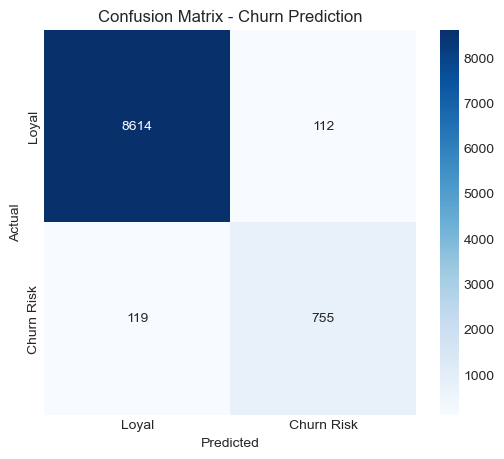

In [21]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")
print(f"Churn rate: {y.mean()*100:.1f}%")


# ML Pipeline
ml_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


# Train model
ml_pipeline.fit(X_train, y_train)


# Predictions
y_pred = ml_pipeline.predict(X_test)


# Evaluation
print("\n" + "="*50)
print("🤖 ML MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Loyal', 'Churn Risk']))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Loyal', 'Churn Risk'],
            yticklabels=['Loyal', 'Churn Risk'])

plt.title('Confusion Matrix - Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [22]:
# Platform-wise churn
platform_churn = df_all.groupby('platform')['churn'].mean()

print("\n📊 Churn Rate by Platform:")
print(platform_churn)


📊 Churn Rate by Platform:
platform
Ola       0.000000
Rapido    0.570179
Uber      0.244583
Name: churn, dtype: float64


Features: 5000
Importances: 5000


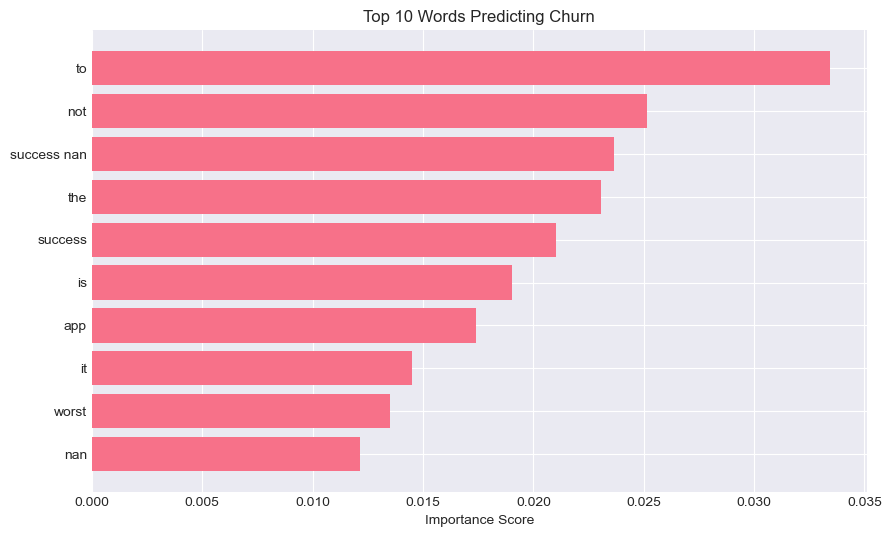


🔑 Top Churn Indicators:
  • 'to' → 0.03344
  • 'not' → 0.02515
  • 'success nan' → 0.02363
  • 'the' → 0.02307
  • 'success' → 0.02103
  • 'is' → 0.01902
  • 'app' → 0.01741
  • 'it' → 0.01449
  • 'worst' → 0.01350
  • 'nan' → 0.01215


In [23]:
# 🔹 Extract feature names from TF-IDF
tfidf = ml_pipeline.named_steps['tfidf']
model = ml_pipeline.named_steps['classifier']

feature_names = tfidf.get_feature_names_out()

# 🔹 Get feature importance (only works for tree models like RandomForest)
importances = model.feature_importances_

# 🔹 Safety check (important)
print("Features:", len(feature_names))
print("Importances:", len(importances))

# 🔹 Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort and get top 20
feature_importance_df = feature_importance_df.sort_values(
    by='importance', ascending=False
).head(20)

# 🔹 Plot Top 10
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['feature'][:10],
    feature_importance_df['importance'][:10]
)

plt.xlabel('Importance Score')
plt.title('Top 10 Words Predicting Churn')
plt.gca().invert_yaxis()
plt.show()


# 🔹 Print Top Features
print("\n🔑 Top Churn Indicators:")
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"  • '{row['feature']}' → {row['importance']:.5f}")

In [24]:
def draw_agent_architecture():
    diagram = """
    ┌──────────────────────────────────────────────────────────────────────┐
    │              🚕 MULTI-AGENT RIDE-HAILING CHURN SYSTEM 🚕              │
    │                        (Uber | Ola | Rapido)                          │
    └──────────────────────────────────────────────────────────────────────┘

    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
    │ 📱 DATA       │    │ 🔄 DATA       │    │ 🧹 DATA       │
    │ COLLECTION    │───▶│ PROCESSING    │───▶│ CLEANING      │
    │ AGENT         │    │ AGENT         │    │ AGENT         │
    └──────────────┘    └──────────────┘    └──────────────┘
           │                    │                    │
           ▼                    ▼                    ▼

    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
    │ 🤖 CHURN      │    │ 📊 SENTIMENT  │    │ 🎯 FEATURE    │
    │ PREDICTION    │◀───│ ANALYSIS      │───▶│ EXTRACTION    │
    │ AGENT         │    │ AGENT         │    │ AGENT         │
    └──────────────┘    └──────────────┘    └──────────────┘
           │                    │                    │
           ▼                    ▼                    ▼

    ┌──────────────────────────────────────────────────────────────┐
    │                      💡 INSIGHTS ENGINE                       │
    │  • High churn due to cancellations & delays                  │
    │  • Pricing dissatisfaction in peak hours                     │
    │  • Driver behavior impacting user retention                  │
    └──────────────────────────────────────────────────────────────┘
           │
           ▼

    ┌──────────────────────────────────────────────────────────────┐
    │                ⚔️ COMPETITION ANALYSIS AGENT                  │
    │        (Compare Uber vs Ola vs Rapido churn trends)          │
    └──────────────────────────────────────────────────────────────┘
           │
           ▼

    ┌──────────────────────────────────────────────────────────────┐
    │               🚀 RECOMMENDATION / ACTION AGENT                │
    │  → Offer discounts to high-risk users                        │
    │  → Improve driver allocation system                          │
    │  → Fix app crashes & UX issues                               │
    │  → Optimize pricing strategy                                 │
    └──────────────────────────────────────────────────────────────┘
    """
    print(diagram)


draw_agent_architecture()


    ┌──────────────────────────────────────────────────────────────────────┐
    │              🚕 MULTI-AGENT RIDE-HAILING CHURN SYSTEM 🚕              │
    │                        (Uber | Ola | Rapido)                          │
    └──────────────────────────────────────────────────────────────────────┘

    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
    │ 📱 DATA       │    │ 🔄 DATA       │    │ 🧹 DATA       │
    │ COLLECTION    │───▶│ PROCESSING    │───▶│ CLEANING      │
    │ AGENT         │    │ AGENT         │    │ AGENT         │
    └──────────────┘    └──────────────┘    └──────────────┘
           │                    │                    │
           ▼                    ▼                    ▼

    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
    │ 🤖 CHURN      │    │ 📊 SENTIMENT  │    │ 🎯 FEATURE    │
    │ PREDICTION    │◀───│ ANALYSIS      │───▶│ EXTRACTION    │
    │ AGENT         │    │ AGENT         │    │ AGENT         │
    └─────────────

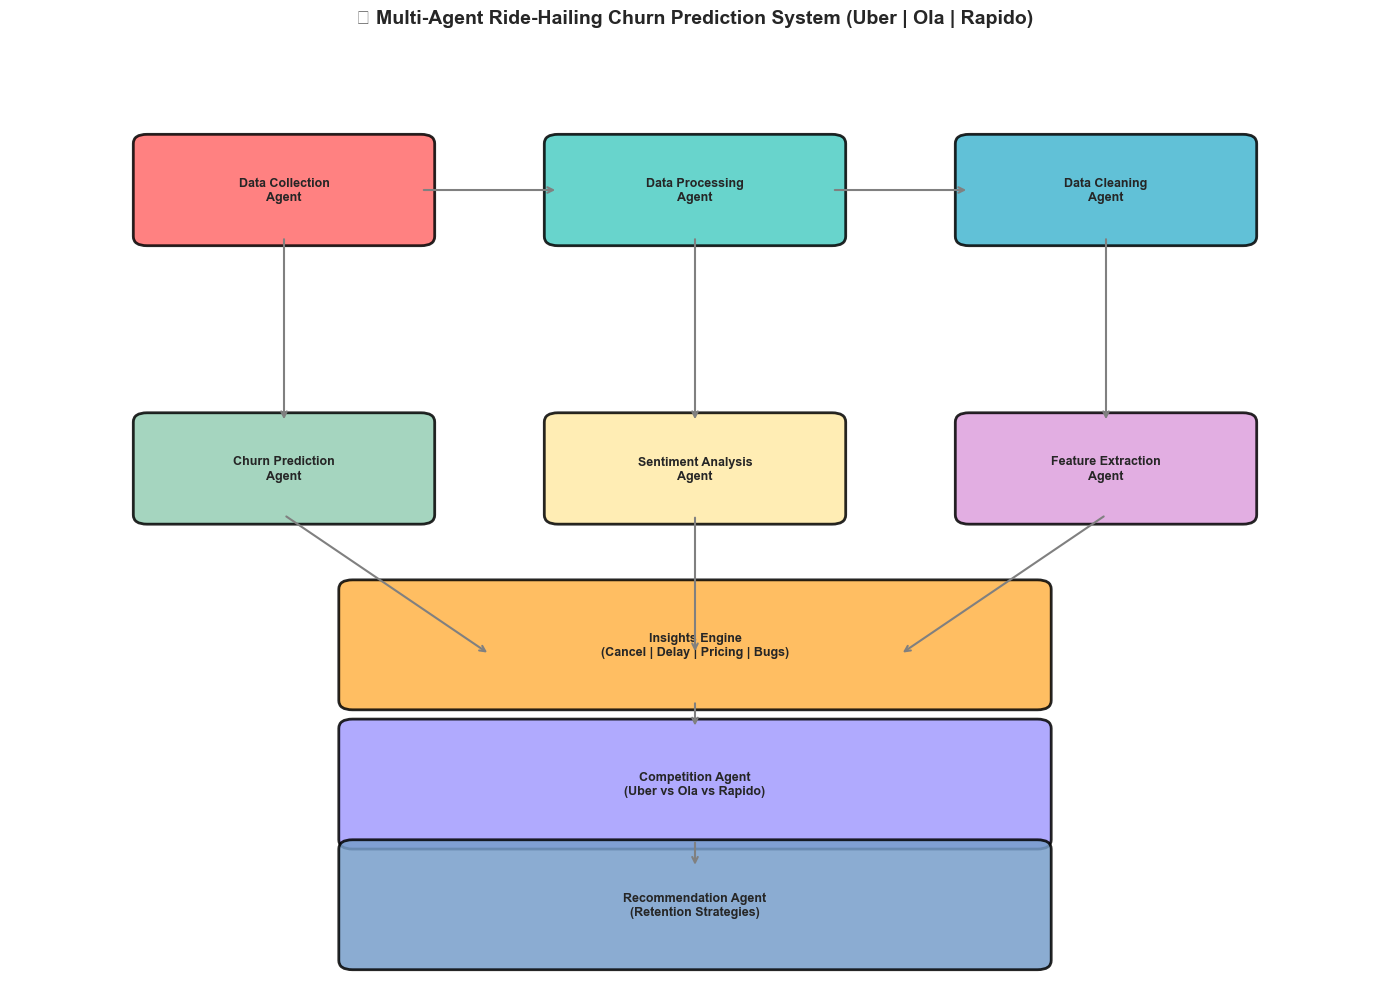

In [25]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt

def create_professional_architecture_diagram():
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.set_title(
        '🚕 Multi-Agent Ride-Hailing Churn Prediction System (Uber | Ola | Rapido)',
        fontsize=14, fontweight='bold', pad=20
    )

    # 🔹 Define agents (x, y, width, height, color, text)
    agents = [
        (1, 8, 2, 1, '#FF6B6B', 'Data Collection\nAgent'),
        (4, 8, 2, 1, '#4ECDC4', 'Data Processing\nAgent'),
        (7, 8, 2, 1, '#45B7D1', 'Data Cleaning\nAgent'),

        (1, 5, 2, 1, '#96CEB4', 'Churn Prediction\nAgent'),
        (4, 5, 2, 1, '#FFEAA7', 'Sentiment Analysis\nAgent'),
        (7, 5, 2, 1, '#DDA0DD', 'Feature Extraction\nAgent'),

        (2.5, 3, 5, 1.2, '#FFB347', 'Insights Engine\n(Cancel | Delay | Pricing | Bugs)'),

        (2.5, 1.5, 5, 1.2, '#A29BFE', 'Competition Agent\n(Uber vs Ola vs Rapido)'),

        (2.5, 0.2, 5, 1.2, '#779ECB', 'Recommendation Agent\n(Retention Strategies)')
    ]

    # 🔹 Draw boxes
    for x, y, w, h, color, text in agents:
        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor='black',
            linewidth=2,
            alpha=0.85
        )
        ax.add_patch(box)

        ax.text(
            x + w/2, y + h/2, text,
            ha='center', va='center',
            fontsize=9, fontweight='bold'
        )

    # 🔹 Draw arrows (flow)
    arrows = [
        (3, 8.5, 4, 8.5), (6, 8.5, 7, 8.5),

        (2, 8, 2, 6), (5, 8, 5, 6), (8, 8, 8, 6),

        (2, 5, 3.5, 3.5), (5, 5, 5, 3.5), (8, 5, 6.5, 3.5),

        (5, 3, 5, 2.7),
        (5, 1.5, 5, 1.2)
    ]

    for x1, y1, x2, y2 in arrows:
        ax.annotate(
            '',
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray')
        )

    plt.tight_layout()
    plt.show()


create_professional_architecture_diagram()

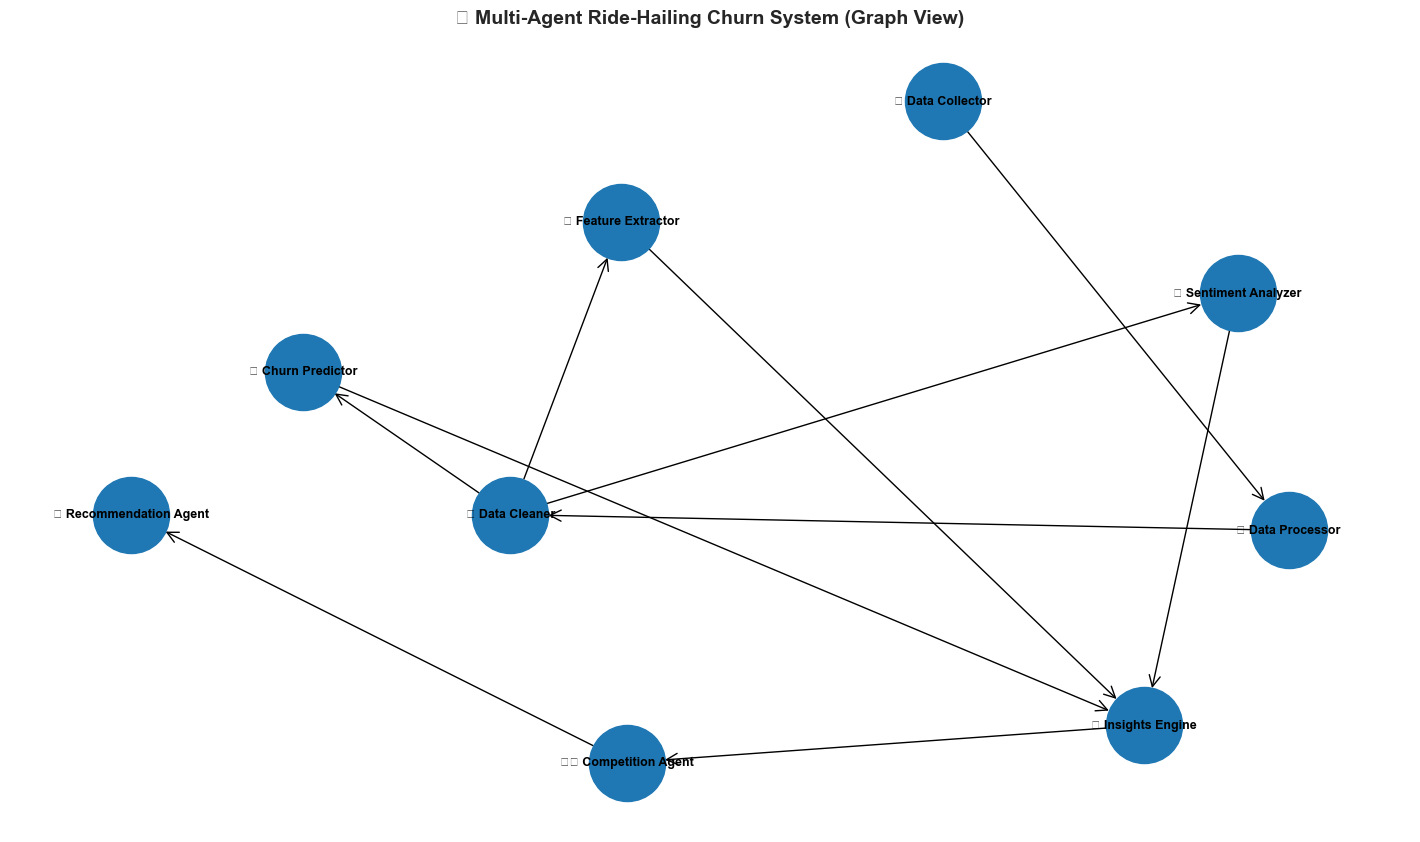

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

def create_graph_architecture():
    G = nx.DiGraph()

    # 🔹 Define agents (more advanced)
    agents = {
        '📱 Data Collector': 'input',
        '🔄 Data Processor': 'process',
        '🧹 Data Cleaner': 'process',
        '🤖 Churn Predictor': 'ml',
        '📊 Sentiment Analyzer': 'ml',
        '🎯 Feature Extractor': 'ml',
        '💡 Insights Engine': 'core',
        '⚔️ Competition Agent': 'core',
        '🚀 Recommendation Agent': 'output'
    }

    # Add nodes
    for agent in agents.keys():
        G.add_node(agent)

    # 🔹 Define edges (multi-agent interaction)
    edges = [
        ('📱 Data Collector', '🔄 Data Processor'),
        ('🔄 Data Processor', '🧹 Data Cleaner'),

        # Parallel intelligence
        ('🧹 Data Cleaner', '🤖 Churn Predictor'),
        ('🧹 Data Cleaner', '📊 Sentiment Analyzer'),
        ('🧹 Data Cleaner', '🎯 Feature Extractor'),

        # Combine outputs
        ('🤖 Churn Predictor', '💡 Insights Engine'),
        ('📊 Sentiment Analyzer', '💡 Insights Engine'),
        ('🎯 Feature Extractor', '💡 Insights Engine'),

        # Business logic
        ('💡 Insights Engine', '⚔️ Competition Agent'),

        # Final action
        ('⚔️ Competition Agent', '🚀 Recommendation Agent')
    ]

    G.add_edges_from(edges)

    # 🔹 Draw graph
    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, k=1.8, seed=42)

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        font_size=9,
        font_weight='bold',
        arrows=True,
        arrowstyle='->',
        arrowsize=20
    )

    plt.title(
        '🚕 Multi-Agent Ride-Hailing Churn System (Graph View)',
        fontsize=14,
        fontweight='bold'
    )

    plt.show()


create_graph_architecture()


Random Forest:
  Accuracy: 0.909 (+/- 0.116)
  F1 Score: 0.743 (+/- 0.211)

Logistic Regression:
  Accuracy: 0.916 (+/- 0.107)
  F1 Score: 0.752 (+/- 0.199)

Gradient Boosting:
  Accuracy: 0.897 (+/- 0.119)
  F1 Score: 0.675 (+/- 0.170)

Linear SVM:
  Accuracy: 0.927 (+/- 0.088)
  F1 Score: 0.769 (+/- 0.190)


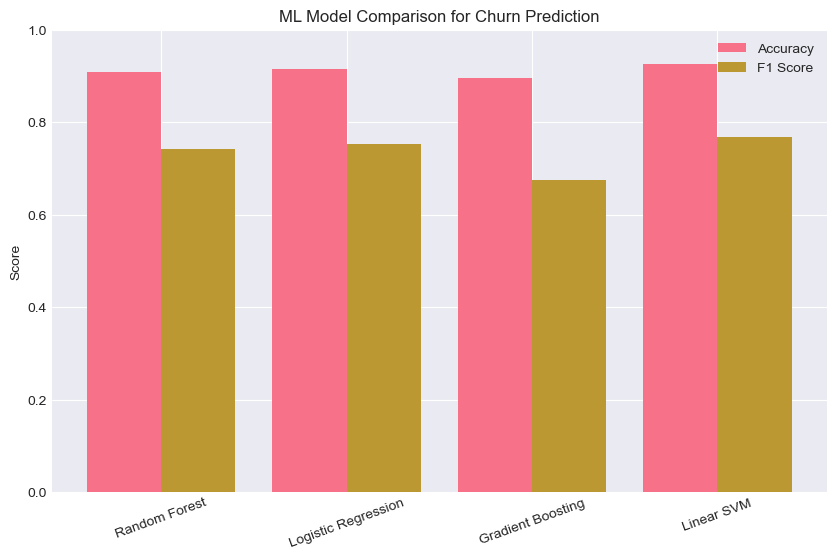

In [27]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score

# 🔹 Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42)
}

# 🔹 Scoring metrics (important!)
scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score)
}

results = {}

# 🔹 Train + Evaluate
for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('clf', model)
    ])
    
    cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)
    
    results[name] = {
        'accuracy_mean': cv_results['test_accuracy'].mean(),
        'accuracy_std': cv_results['test_accuracy'].std(),
        'f1_mean': cv_results['test_f1'].mean(),
        'f1_std': cv_results['test_f1'].std()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {results[name]['accuracy_mean']:.3f} (+/- {results[name]['accuracy_std']:.3f})")
    print(f"  F1 Score: {results[name]['f1_mean']:.3f} (+/- {results[name]['f1_std']:.3f})")


# 🔹 Visualization
plt.figure(figsize=(10, 6))

model_names = list(results.keys())
accuracy_scores = [results[m]['accuracy_mean'] for m in model_names]
f1_scores = [results[m]['f1_mean'] for m in model_names]

x = range(len(model_names))

plt.bar(x, accuracy_scores, width=0.4, label='Accuracy')
plt.bar([i + 0.4 for i in x], f1_scores, width=0.4, label='F1 Score')

plt.xticks([i + 0.2 for i in x], model_names, rotation=20)
plt.ylabel('Score')
plt.title('ML Model Comparison for Churn Prediction')
plt.legend()

plt.ylim(0, 1)
plt.show()

In [36]:
ml_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [38]:
result = predict_churn_risk("App is very slow and driver cancelled", 2)
print(result)

{'review': 'App is very slow and driver cancelled...', 'churn_probability': np.float64(0.662), 'risk_level': 'MEDIUM', 'recommended_action': '⚠️ Engagement: personalized offers + notifications'}


In [39]:
def predict_churn_risk(review_text, rating=None):
    """
    Predict churn risk based on review text and optional rating
    """

    # 🔹 Default values
    churn_prob = None
    risk = "UNKNOWN"
    action = "No action"

    # 🔹 Step 1: Rule-based (rating)
    if rating is not None:
        if rating <= 2:
            risk = "HIGH"
        elif rating == 3:
            risk = "MEDIUM"
        else:
            risk = "LOW"

    # 🔹 Step 2: ML prediction (handle models without predict_proba like SVM)
    if hasattr(ml_pipeline, "predict_proba"):
        churn_prob = ml_pipeline.predict_proba([review_text])[0][1]
    else:
        pred = ml_pipeline.predict([review_text])[0]
        churn_prob = float(pred)  # fallback (0 or 1)

    # 🔹 Step 3: Final decision (ML overrides rule-based if strong)
    if churn_prob >= 0.7:
        risk = "HIGH"
        action = "🚨 Immediate retention: discount + priority support"
    elif churn_prob >= 0.4:
        risk = "MEDIUM"
        action = "⚠️ Engagement: personalized offers + notifications"
    else:
        risk = "LOW"
        action = "✅ Retain: loyalty rewards + engagement emails"

    # 🔹 Step 4: Return structured output
    return {
        'review': review_text[:100] + "...",
        'churn_probability': round(churn_prob, 3),
        'risk_level': risk,
        'recommended_action': action
    }


# 🔹 Test the function
test_reviews = [
    ("Driver cancelled my ride 3 times in a row, horrible experience!", 1),
    ("Great service, always on time and reasonable prices", 5),
    ("App keeps crashing when I try to book a ride", 2)
]

print("\n" + "="*60)
print("🎯 REAL-TIME CHURN PREDICTION")
print("="*60)

for review, rating in test_reviews:
    result = predict_churn_risk(review, rating)

    print(f"\n📝 Review: {result['review']}")
    print(f"⭐ Rating: {rating}")
    print(f"⚠️ Churn Probability: {result['churn_probability']:.1%}")
    print(f"🚦 Risk Level: {result['risk_level']}")
    print(f"💡 Action: {result['recommended_action']}")


🎯 REAL-TIME CHURN PREDICTION

📝 Review: Driver cancelled my ride 3 times in a row, horrible experience!...
⭐ Rating: 1
⚠️ Churn Probability: 76.0%
🚦 Risk Level: HIGH
💡 Action: 🚨 Immediate retention: discount + priority support

📝 Review: Great service, always on time and reasonable prices...
⭐ Rating: 5
⚠️ Churn Probability: 1.0%
🚦 Risk Level: LOW
💡 Action: ✅ Retain: loyalty rewards + engagement emails

📝 Review: App keeps crashing when I try to book a ride...
⭐ Rating: 2
⚠️ Churn Probability: 58.0%
🚦 Risk Level: MEDIUM
💡 Action: ⚠️ Engagement: personalized offers + notifications


In [40]:
import json

# 🔹 Get best model based on F1 score (better than accuracy for churn)
best_model = max(results, key=lambda x: results[x]['f1_mean'])

# 🔹 Generate insights report
insights = {
    'top_churn_reasons': feature_importance_df.head(5)['feature'].tolist(),
    'best_model': best_model,
    'model_accuracy': results[best_model]['accuracy_mean'],
    'model_f1_score': results[best_model]['f1_mean'],
    'churn_rate': f"{y.mean()*100:.1f}%",
    
    'recommendations': [
        "Implement transparent pricing to reduce dissatisfaction",
        "Reduce driver cancellations through better incentives",
        "Fix app crashes and improve app stability",
        "Improve driver allocation to reduce wait times",
        "Introduce loyalty rewards for frequent users"
    ]
}

# 🔹 Save insights
with open('churn_insights.json', 'w') as f:
    json.dump(insights, f, indent=2)

# 🔹 Print report
print("✅ Insights saved to churn_insights.json")

print("\n📊 FINAL BUSINESS REPORT")
print("="*50)

print(f"🚀 Best Model: {insights['best_model']}")
print(f"📈 Accuracy: {insights['model_accuracy']:.2%}")
print(f"🎯 F1 Score: {insights['model_f1_score']:.2%}")
print(f"⚠️ Churn Rate: {insights['churn_rate']}")

print("\n🔑 Top 5 Churn Indicators:")
for i, reason in enumerate(insights['top_churn_reasons'], 1):
    print(f"  {i}. '{reason}'")

print("\n💡 Business Recommendations:")
for i, rec in enumerate(insights['recommendations'], 1):
    print(f"  {i}. {rec}")

✅ Insights saved to churn_insights.json

📊 FINAL BUSINESS REPORT
🚀 Best Model: Linear SVM
📈 Accuracy: 92.72%
🎯 F1 Score: 76.92%
⚠️ Churn Rate: 9.1%

🔑 Top 5 Churn Indicators:
  1. 'success nan'
  2. 'success'
  3. 'worst'
  4. 'they'
  5. 'good'

💡 Business Recommendations:
  1. Implement transparent pricing to reduce dissatisfaction
  2. Reduce driver cancellations through better incentives
  3. Fix app crashes and improve app stability
  4. Improve driver allocation to reduce wait times
  5. Introduce loyalty rewards for frequent users
